In [1]:

#@title Importando bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import optuna


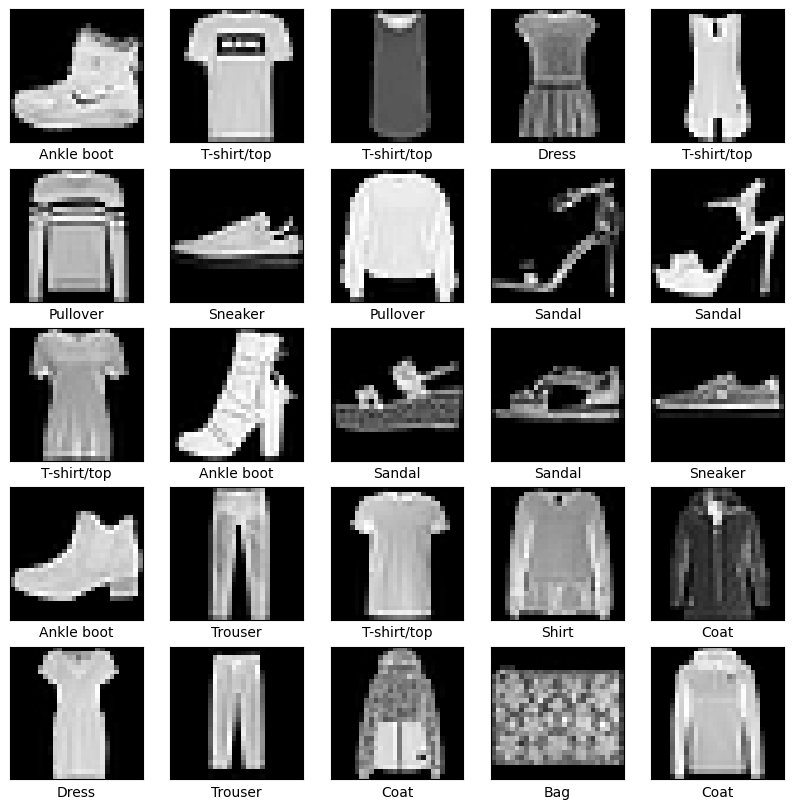

In [2]:
# Loading dataset and scaling values
dataset = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = dataset.load_data()

class_names = {
    0: 'T-shirt/top',
    1: 'Trouser', 
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Scale values to a range of 0 to 1 by dividing by the max value, in this case its 255
train_images = train_images / 255.0
test_images = test_images / 255.0

train_labels_onehot = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_onehot = tf.keras.utils.to_categorical(test_labels, num_classes=10)

# Display first 25 images and labels
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [4]:
def create_model(neurons: int, layers: int) -> tf.keras.Model:
    """
    Creates a sequential neural network model.
    
    Args:
        neurons: Number of neurons in each hidden layer
        layers: Number of hidden layers
        
    Returns:
        A compiled TensorFlow Keras Model
    """

    # Default input of the current network
    # Input layer
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(28,28)))
    model.add(tf.keras.layers.Flatten())
    # Hidden layers
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(neurons, activation="relu"))
        model.add(tf.keras.layers.Dropout(0.25))
        
    # Output layer
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    return model

[I 2025-12-09 20:53:50,953] A new study created in RDB with name: val_f1_score_optv5


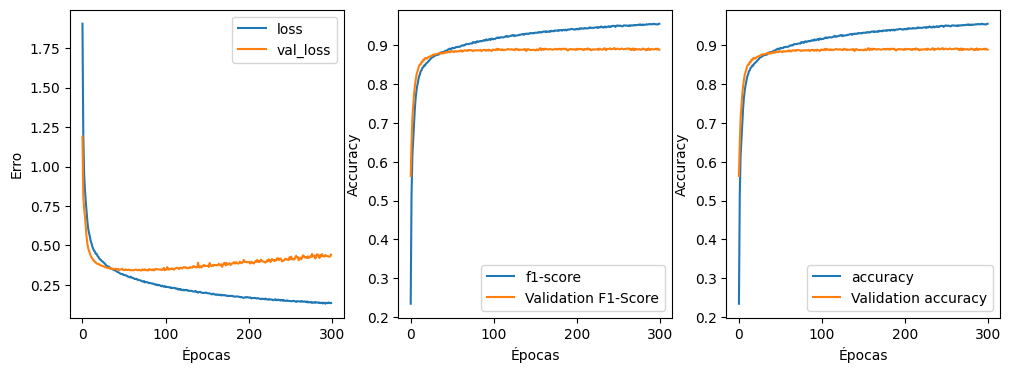

[I 2025-12-09 21:12:32,883] Trial 0 finished with value: 0.8891332745552063 and parameters: {'layers': 7, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 4.23169466446741e-05}. Best is trial 0 with value: 0.8891332745552063.


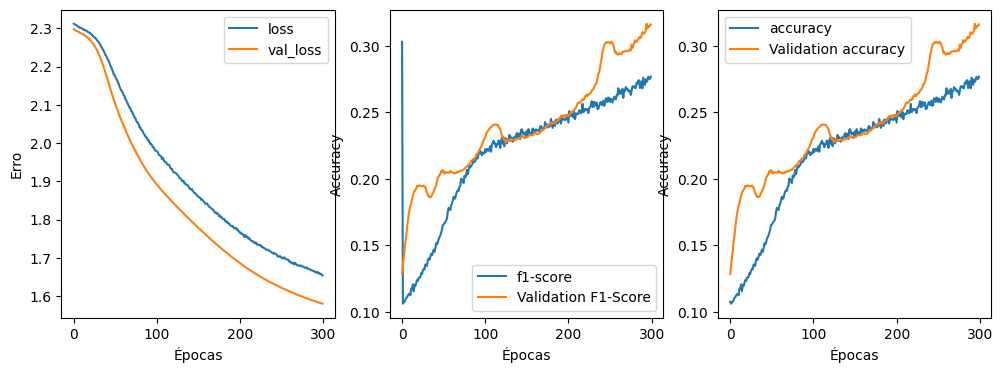

[I 2025-12-09 21:23:33,462] Trial 1 finished with value: 0.31599995493888855 and parameters: {'layers': 7, 'neurons': 64, 'optimizer': 'sgd', 'learning_rate': 4.217370321921481e-05}. Best is trial 0 with value: 0.8891332745552063.


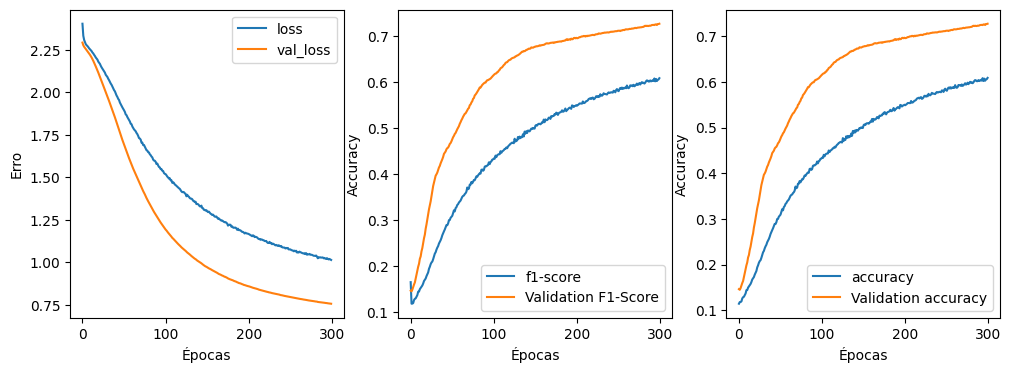

[I 2025-12-09 21:32:25,384] Trial 2 finished with value: 0.727400004863739 and parameters: {'layers': 4, 'neurons': 32, 'optimizer': 'sgd', 'learning_rate': 6.813035386171833e-05}. Best is trial 0 with value: 0.8891332745552063.


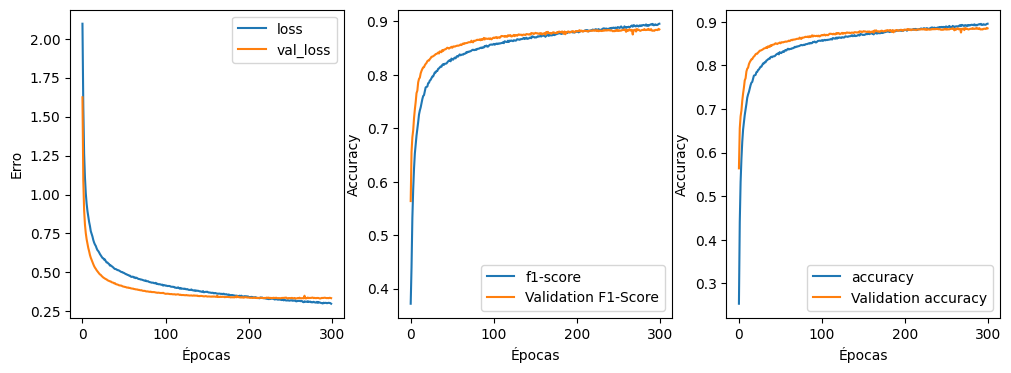

[I 2025-12-09 21:41:32,556] Trial 3 finished with value: 0.8848666548728943 and parameters: {'layers': 3, 'neurons': 64, 'optimizer': 'sgd', 'learning_rate': 0.0014768168754515356}. Best is trial 0 with value: 0.8891332745552063.


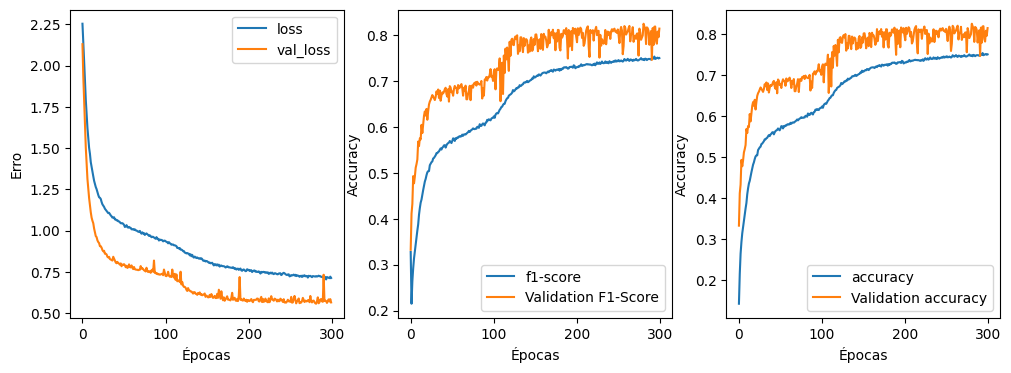

[I 2025-12-09 21:49:49,317] Trial 4 finished with value: 0.8149333000183105 and parameters: {'layers': 4, 'neurons': 16, 'optimizer': 'sgd', 'learning_rate': 0.0023762278672729053}. Best is trial 0 with value: 0.8891332745552063.


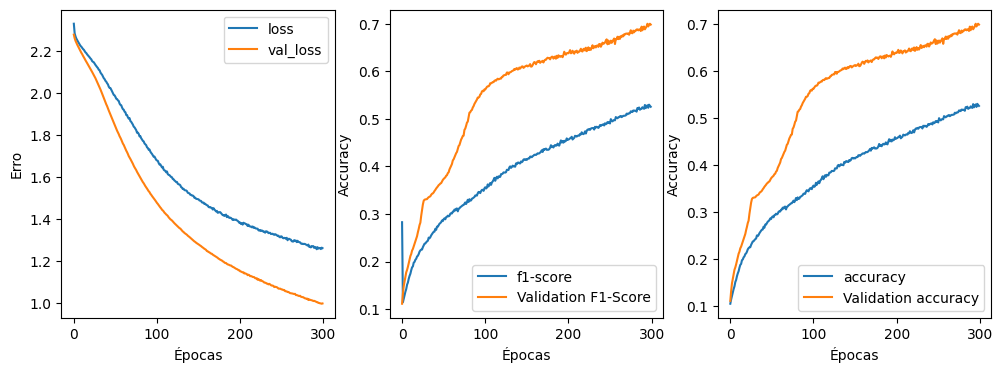

[I 2025-12-09 21:58:06,614] Trial 5 finished with value: 0.6981999278068542 and parameters: {'layers': 4, 'neurons': 16, 'optimizer': 'sgd', 'learning_rate': 0.00012680244563394408}. Best is trial 0 with value: 0.8891332745552063.


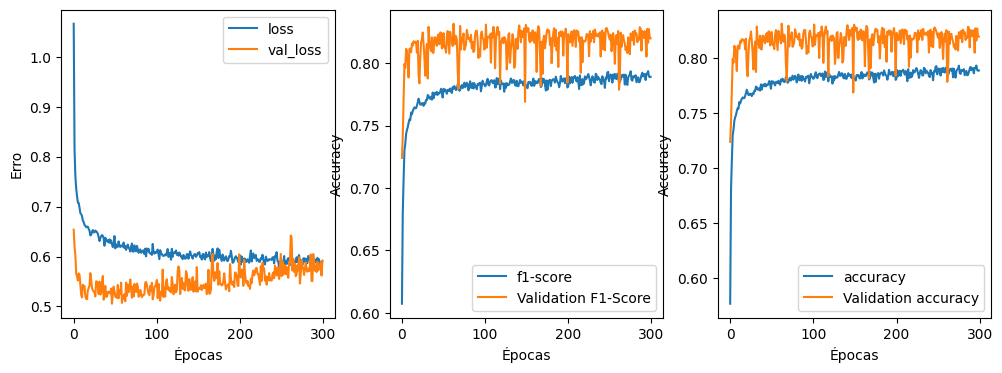

[I 2025-12-09 22:07:27,950] Trial 6 finished with value: 0.8197332620620728 and parameters: {'layers': 4, 'neurons': 32, 'optimizer': 'adam', 'learning_rate': 0.002133113597628186}. Best is trial 0 with value: 0.8891332745552063.


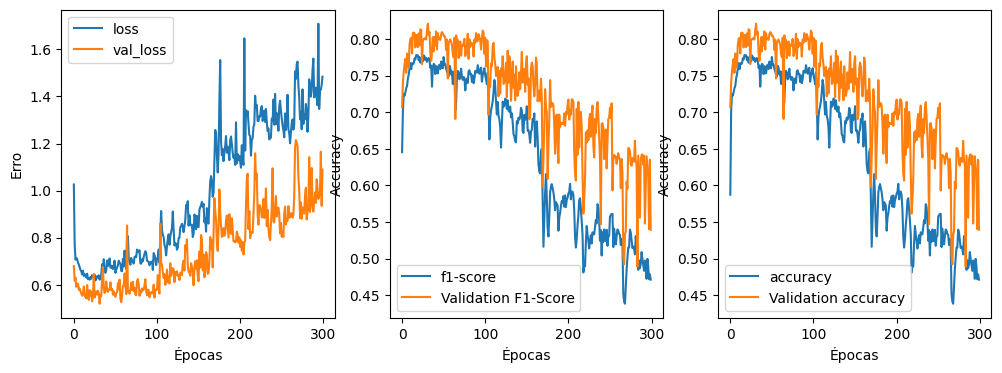

[I 2025-12-09 22:28:01,161] Trial 7 finished with value: 0.5394666194915771 and parameters: {'layers': 9, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.00185548719046855}. Best is trial 0 with value: 0.8891332745552063.


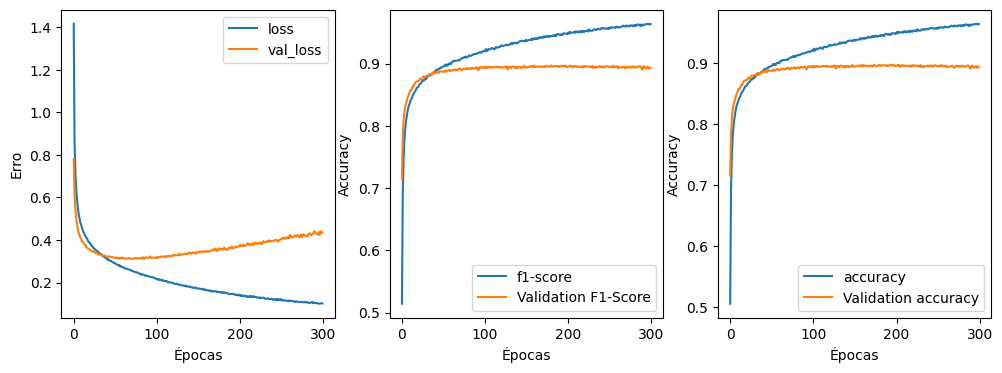

[I 2025-12-09 22:42:49,603] Trial 8 finished with value: 0.893466591835022 and parameters: {'layers': 3, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 3.633062238518574e-05}. Best is trial 8 with value: 0.893466591835022.


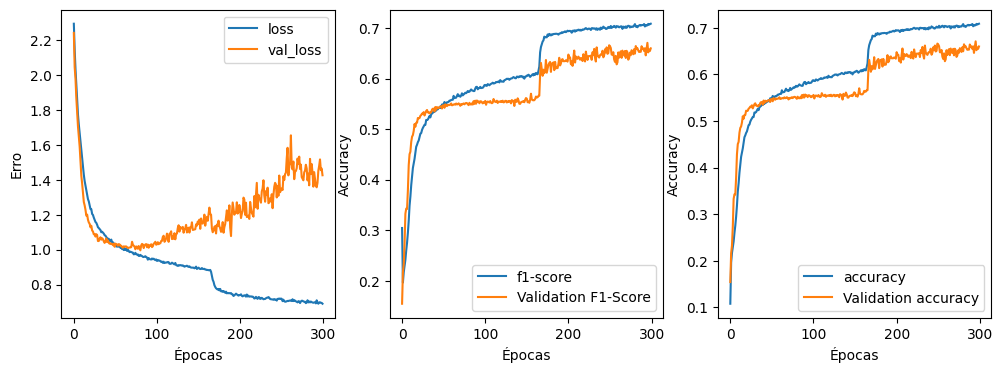

[I 2025-12-09 22:57:07,329] Trial 9 finished with value: 0.6598666310310364 and parameters: {'layers': 10, 'neurons': 32, 'optimizer': 'adam', 'learning_rate': 5.393348069701802e-05}. Best is trial 8 with value: 0.893466591835022.


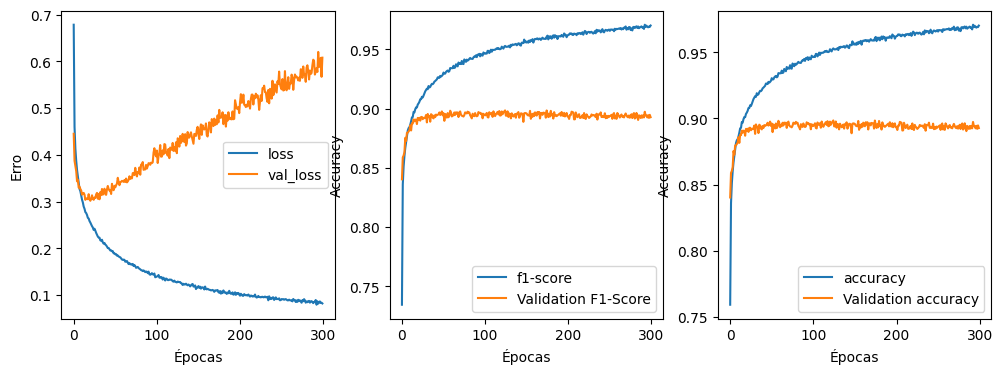

[I 2025-12-09 23:09:00,932] Trial 10 finished with value: 0.8927332758903503 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.00039561347871020647}. Best is trial 8 with value: 0.893466591835022.


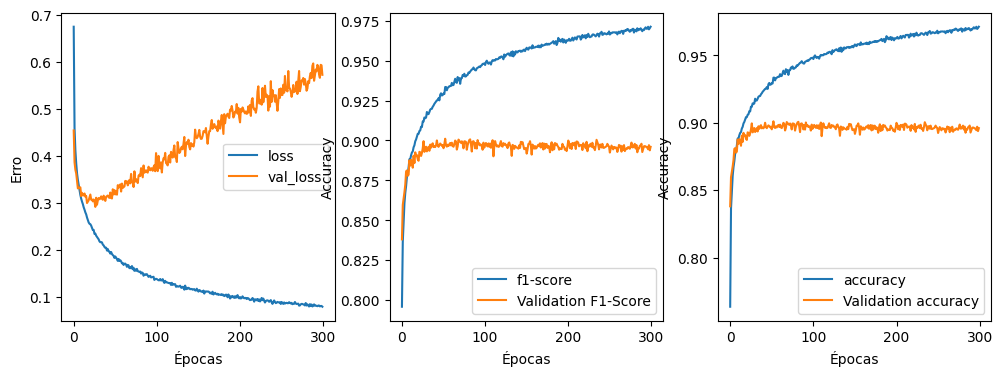

[I 2025-12-09 23:20:22,550] Trial 11 finished with value: 0.8959999680519104 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.000421864760976589}. Best is trial 11 with value: 0.8959999680519104.


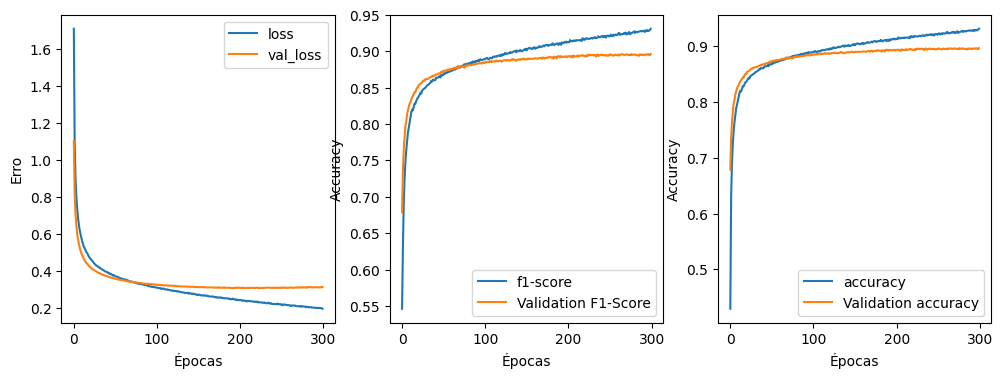

[I 2025-12-09 23:31:43,184] Trial 12 finished with value: 0.8962665796279907 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 1.4200120418151348e-05}. Best is trial 12 with value: 0.8962665796279907.


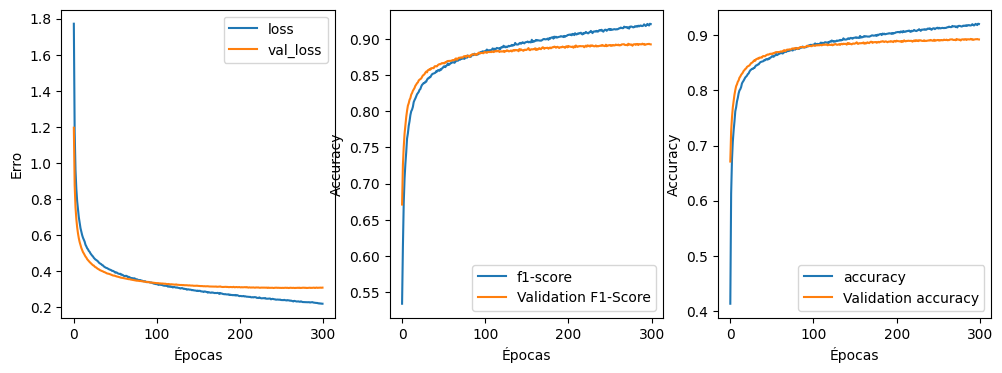

[I 2025-12-09 23:43:01,197] Trial 13 finished with value: 0.8924666047096252 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 1.1222442806263784e-05}. Best is trial 12 with value: 0.8962665796279907.


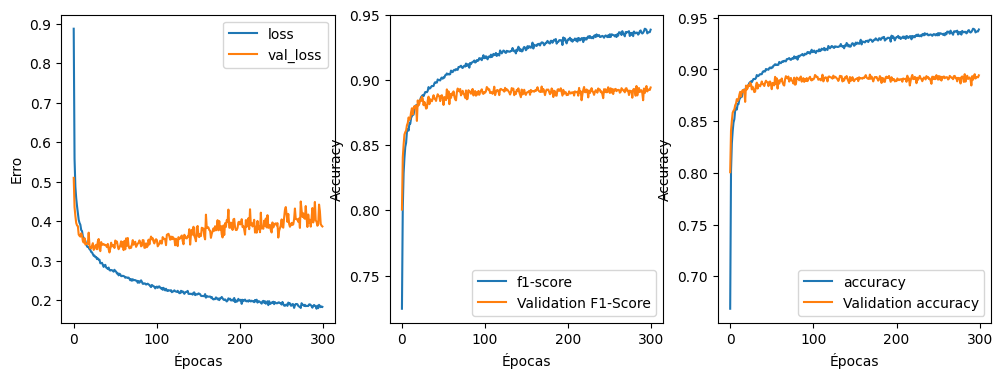

[I 2025-12-09 23:58:31,762] Trial 14 finished with value: 0.8943333029747009 and parameters: {'layers': 6, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.0005083991384484217}. Best is trial 12 with value: 0.8962665796279907.


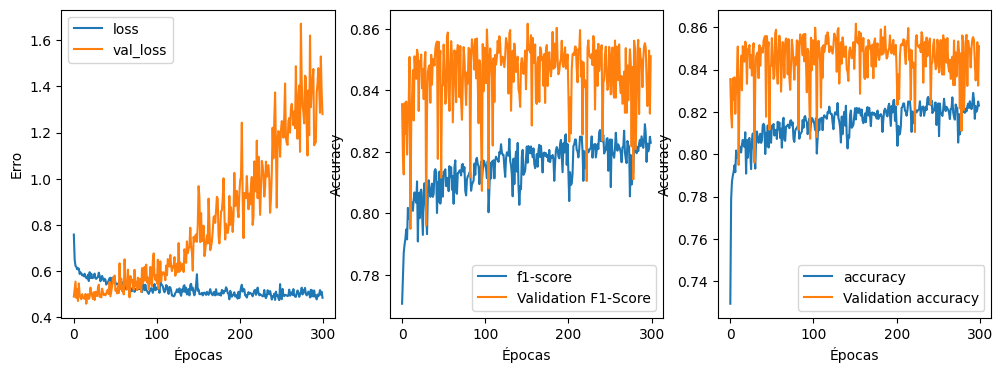

[I 2025-12-10 00:09:48,310] Trial 15 finished with value: 0.8511332869529724 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.007223016470841828}. Best is trial 12 with value: 0.8962665796279907.


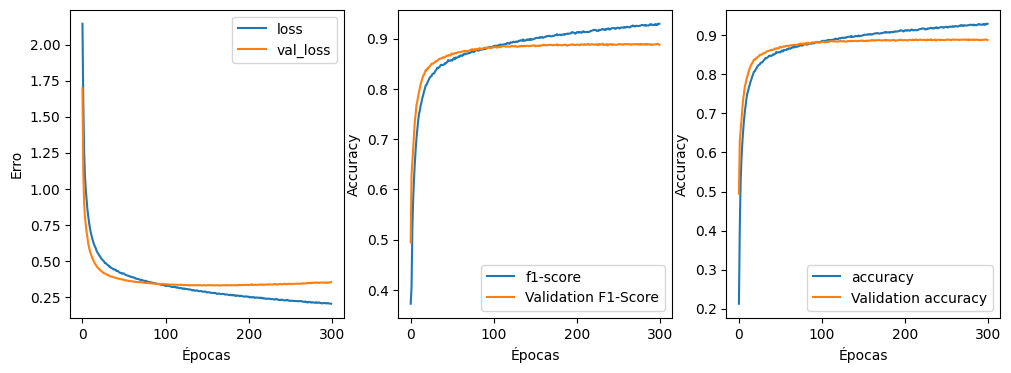

[I 2025-12-10 00:24:30,236] Trial 16 finished with value: 0.8877999186515808 and parameters: {'layers': 5, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 1.2507783939503488e-05}. Best is trial 12 with value: 0.8962665796279907.


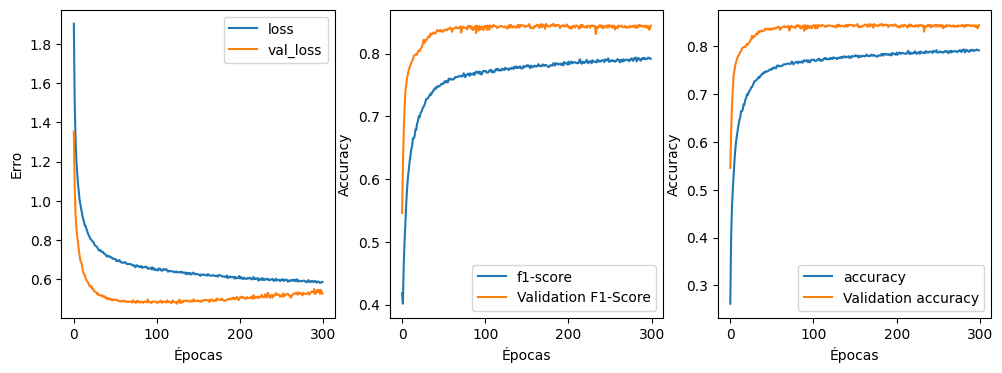

[I 2025-12-10 00:33:28,878] Trial 17 finished with value: 0.8444666266441345 and parameters: {'layers': 3, 'neurons': 16, 'optimizer': 'adam', 'learning_rate': 0.00014824567840211004}. Best is trial 12 with value: 0.8962665796279907.


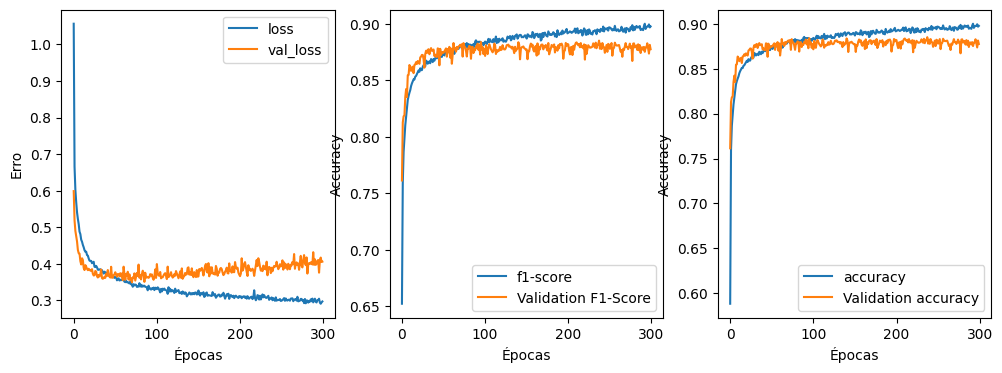

[I 2025-12-10 00:46:22,450] Trial 18 finished with value: 0.8776666522026062 and parameters: {'layers': 6, 'neurons': 64, 'optimizer': 'adam', 'learning_rate': 0.0007531939852277007}. Best is trial 12 with value: 0.8962665796279907.


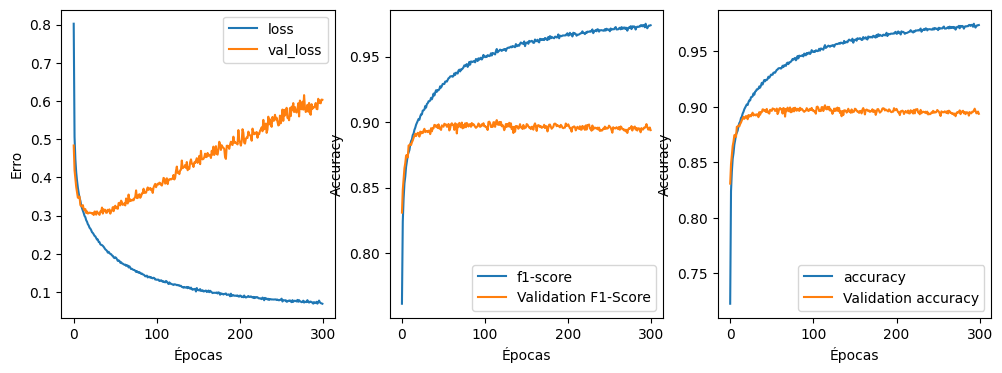

[I 2025-12-10 00:58:59,482] Trial 19 finished with value: 0.8938665986061096 and parameters: {'layers': 2, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.00017879310504708006}. Best is trial 12 with value: 0.8962665796279907.
[W 2025-12-10 01:02:57,289] Trial 20 failed with parameters: {'layers': 8, 'neurons': 128, 'optimizer': 'adam', 'learning_rate': 0.009632550506493604} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\ribei\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\ribei\AppData\Local\Temp\ipykernel_20504\1662552871.py", line 39, in objective
    training = rna.fit(
        train_images, train_labels_onehot,
    ...<5 lines>...
    
    )
  File "C:\Users\ribei\AppData\Roaming\Python\Python313\site-packages\keras\src\utils\traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)


KeyboardInterrupt: 

In [ ]:


f1_metric = tf.keras.metrics.F1Score(average='micro', name='f1_score')

class myCallback(tf.keras.callbacks.Callback):
 def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_accuracy')>=0.92):
        print("\nReached 92% accuracy so cancelling training!")
        self.model.stop_training = True



callback = myCallback()



def objective(trial):
    layers = trial.suggest_int("layers", 2, 10)
    neurons = trial.suggest_categorical("neurons", [16, 32, 64, 128])
    
    optimizer = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    
    rna = create_model(neurons, layers)
    
    # Simple optimizer mapping
    optimizer_configs = {
        "adam": tf.keras.optimizers.Adam(learning_rate=learning_rate),
        "sgd": tf.keras.optimizers.SGD(learning_rate=learning_rate),
    }
    
    optimizer = optimizer_configs[optimizer]
    
    # Training
    rna.compile(optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy', f1_metric])
    
   
    
    training = rna.fit(
        train_images, train_labels_onehot,
        epochs=300,  
        verbose=0,
        validation_split=0.25,
        # batch_size=batch_sizes,
        callbacks=[callback]
        
    )
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(training.history['loss'], label='loss')
    plt.plot(training.history['val_loss'], label='val_loss')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Erro')

    plt.subplot(1, 3, 2)
    plt.plot(training.history['f1_score'], label='f1-score')
    plt.plot(training.history['val_f1_score'], label='Validation F1-Score')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    
    plt.subplot(1, 3, 3)
    plt.plot(training.history['accuracy'], label='accuracy')
    plt.plot(training.history['val_accuracy'], label='Validation accuracy')
    plt.legend()
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')

    plt.show()
        
    return training.history['val_f1_score'][-1] # training.history['val_loss'][-1], 

study = optuna.create_study(directions=['maximize']) # 
study.optimize(objective, n_trials=200)
    
    

In [111]:
print(study.best_trials)


for i, trial in enumerate(study.best_trials):
    print(f"Pareto optimal trial {i}:")
    print(f"  Parameters: {trial.params}")
    print(f"  Values: {trial.values}")
    print(f"  Number: {trial.number}")


#     

[FrozenTrial(number=4, state=<TrialState.COMPLETE: 1>, values=[0.8889443874359131], datetime_start=datetime.datetime(2025, 11, 20, 12, 55, 26, 780685), datetime_complete=datetime.datetime(2025, 11, 20, 13, 6, 12, 765676), params={'layers': 3, 'neurons': 128, 'optimizer': 'sgd', 'learning_rate': 0.0013506125953021764}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'layers': IntDistribution(high=10, log=False, low=2, step=1), 'neurons': CategoricalDistribution(choices=(16, 32, 64, 128)), 'optimizer': CategoricalDistribution(choices=('adam', 'sgd')), 'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None)}, trial_id=13, value=None)]
Pareto optimal trial 0:
  Parameters: {'layers': 3, 'neurons': 128, 'optimizer': 'sgd', 'learning_rate': 0.0013506125953021764}
  Values: [0.8889443874359131]
  Number: 4


In [6]:
# Neural Network
best_model = create_model(neurons=128, layers=2)
# 'layers': 2, 'neurons': 128, 'optimizer': 'sgd', 'learning_rate': 0.0035434543456900718


# 'layers': 8, 'neurons': 128, 'optimizer': 'rmsprop', 'learning_rate': 2.5938152425188507e-05
# 'layers': 5, 'neurons': 16, 'optimizer': 'adam', 'learning_rate': 0.0044816323179990855
# 'layers': 10, 'neurons': 32, 'optimizer': 'sgd', 'learning_rate': 0.008949012372303415b
# 134794

best_model.count_params()

118282

Epoch 1/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9427 - f1_score: 0.9303 - loss: 0.1583 - val_accuracy: 0.8935 - val_f1_score: 0.8935 - val_loss: 0.3260
Epoch 2/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9410 - f1_score: 0.9410 - loss: 0.1610 - val_accuracy: 0.8931 - val_f1_score: 0.8931 - val_loss: 0.3359
Epoch 3/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9423 - f1_score: 0.9423 - loss: 0.1587 - val_accuracy: 0.8933 - val_f1_score: 0.8933 - val_loss: 0.3236
Epoch 4/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9429 - f1_score: 0.9429 - loss: 0.1589 - val_accuracy: 0.8893 - val_f1_score: 0.8893 - val_loss: 0.3427
Epoch 5/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9429 - f1_score: 0.9429 - loss: 0.1576 - val_accuracy: 0.8930 - val_f1_score: 0.8930 - val_loss: 0.3289
Epoch 6/300
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9429 - f1_score: 0.9429 - loss: 0.1565 - val_accuracy: 0.8921 - va

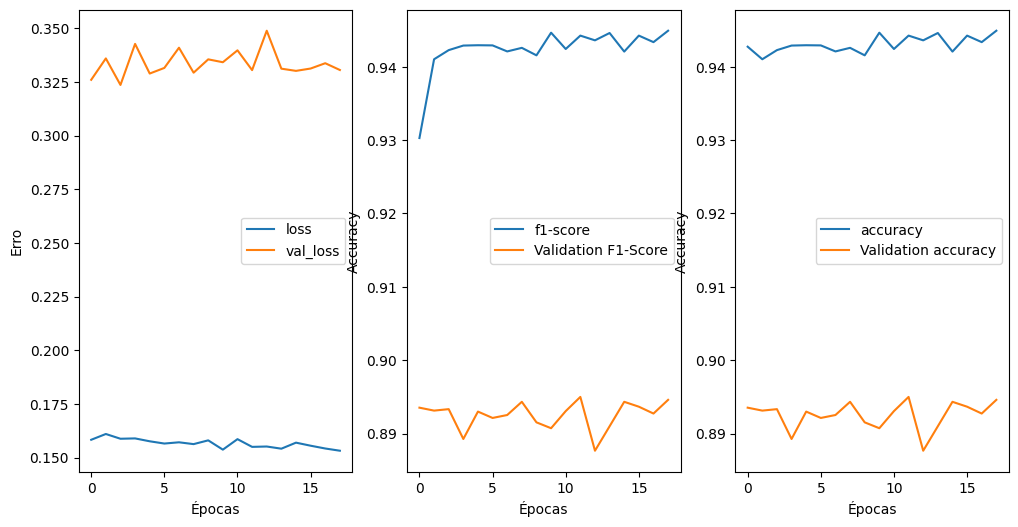

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.83      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.83      0.81      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.83      0.80      0.82      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.71      0.70      0.71      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



<Figure size 640x480 with 0 Axes>

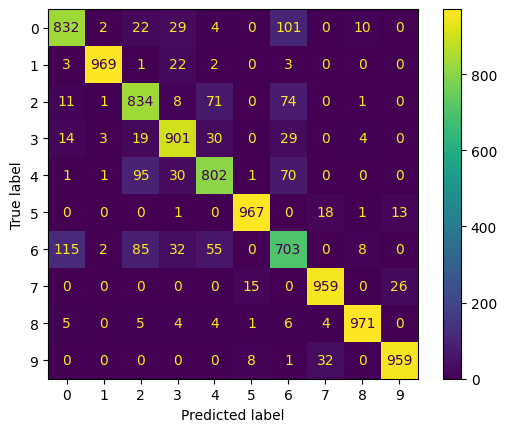

In [10]:
# Compile
# 'layers': 4, 'neurons': 16, 'optimizer': 'adam', 'learning_rate': 0.0006737171696927297
class myCallback(tf.keras.callbacks.Callback):
 def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_accuracy')==0.90):
        print("\nReached 90% accuracy so cancelling training!")
        self.model.stop_training = True



callback = myCallback()


opt = tf.keras.optimizers.SGD(learning_rate=0.0035434543456900718)
best_model.compile(optimizer=opt, 
            loss='categorical_crossentropy',
            metrics=['accuracy', f1_metric]) 

training = best_model.fit(
        train_images, train_labels_onehot,
        epochs=300,  
        verbose=1,
        validation_split=0.25,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]
    )


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(training.history['loss'], label='loss')
plt.plot(training.history['val_loss'], label='val_loss')
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Erro')

plt.subplot(1, 3, 2)
plt.plot(training.history['f1_score'], label='f1-score')
plt.plot(training.history['val_f1_score'], label='Validation F1-Score')
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.subplot(1, 3, 3)
plt.plot(training.history['accuracy'], label='accuracy')
plt.plot(training.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.show()



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y = best_model.predict(test_images)
# Posição de maior probabilidade
preds = np.argmax(y, axis=1)

# Grafico
plt.figure()
cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names.keys())
disp.plot()


print(classification_report(test_labels, preds, target_names=class_names.values()))
